# Spotiflow in Python

## Overview

[GitHub](https://github.com/weigertlab/spotiflow) | [Paper](https://www.nature.com/articles/s41592-025-02662-x) | [Spotiflow Documentation](https://weigertlab.org/spotiflow/index.html) | [Spotiflow API](https://weigertlab.org/spotiflow/api.html#)

In this notebook, we'll see how to run `Spotiflow` to detect spots on single images or on a folder of images, and how to visualize and save the results.

The images we will use for this section can be downloaded from the <a href="" download> <i class="fas fa-download"></i> Spot Detection Dataset</a>.

## Make sure you have GPU access

To Enable GPU:

1 - Navigate to `Runtime -> Change Runtime Type`

2 - Select `Python 3` as `Runtime Type`

3 - Select one available GPU (e.g. `T4 GPU`) as `Hardware accelerator`.

<br>

<div align="left"> <img src="https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/cellpose/colab_runtime.png" alt="Ilastik Logo" width="400"></div>

## Mount your google drive

To access the data for the course you first need to mount your Google Drive.

Run the cell below to connect your Google Drive to colab and follow the instructions to authenticate your Google account.

You will need to allow access to your Google Drive so that the notebook can read and write files.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Then click on `folder icon` on the left bar, press the `refresh button`. Your Google Drive folder should now be available here (e.g. MyDrive).

<div align="left"> <img src="https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/cellpose/colab_folder.png" alt="Ilastik Logo" width="300"></div>

## Download the Data

Run the cell below to download the data for this exercise and save it in you Google Drive. A new folder called `bobiac_data_spot_detection` will be created in your Google Drive.

In [ ]:
# Create directory
!mkdir -p /content/bobiac_data_spot_detection
# Download the data
!wget https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/data/00_spot_detection.zip -O /content/bobiac_data_cellpose/00_spot_detection.zip
# Unzip the data, remove zip file and macOS metadata files (if any)
!cd /content/bobiac_data_spot_detection && unzip 00_spot_detection.zip && rm -f 00_spot_detection.zip && rm -rf __MACOSX

## Install Cellpose & other dependencies

In [35]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from spotiflow.model import Spotiflow
from tqdm import tqdm

## Setup

These is an helper that saves the results of spot detection in a `.csv` file in a `napari`-compatible format, so that we can easily visualize the results in `napari` later on.

In [76]:
def save_points_as_csv(points, output_path="points.csv", channel_last=False) -> None:
    """Save points as a napari-compatible CSV (drag-and-drop as Points layer).

    napari maps the CSV columns (axis-0, axis-1, ...) to the layer axes in order.
    `predict_multichannel` returns the channel as the *last* column (e.g. (y, x, channel)),
    so set `channel_last=True` to move it to the front (e.g. (channel, y, x)) and have the
    spots line up with a channel-first (C, ...) image in napari.
    """
    points = np.asarray(points)
    if channel_last:
        # move the last column (channel) to the front
        points = points[:, [-1, *range(points.shape[1] - 1)]]
    ndim = points.shape[1]
    headers = ["index"] + [f"axis-{i}" for i in range(ndim)]
    with open(output_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        for i, p in enumerate(points):
            writer.writerow([i, *p])


def plot_points_on_image(image, points, is_3d=False, skip_channels=None):
    """Overlay detected spots on each image channel.

    Works with both predict() (single-channel, no channel column) and
    predict_multichannel() (channel index as last column) outputs.

    Parameters
    ----------
    image : array-like
        2D: (Y, X) or (C, Y, X).  3D: (Z, Y, X) or (C, Z, Y, X).
    points : array-like
        From predict():              (y, x) for 2D,  (z, y, x) for 3D.
        From predict_multichannel(): (y, x, ch) for 2D, (z, y, x, ch) for 3D.
    is_3d : bool
        If True, max-projects along Z before plotting.
    skip_channels : list of int, optional
        Channel indices on which points should NOT be drawn.
    """
    image = np.asarray(image)
    points = np.asarray(points)
    skip_channels = set(skip_channels or [])

    # Detect multichannel by whether points have an extra channel column
    spatial_cols = 3 if is_3d else 2
    is_multichannel = points.shape[1] > spatial_cols

    if is_3d:
        if image.ndim == 3:  # (Z, Y, X) — single channel
            proj = image.max(axis=0)[np.newaxis]  # -> (1, Y, X)
        else:  # (C, Z, Y, X) — multichannel
            proj = image.max(axis=1)  # -> (C, Y, X)
        y_col, x_col = 1, 2
    else:
        if image.ndim == 2:  # (Y, X) — single channel
            proj = image[np.newaxis]  # -> (1, Y, X)
        else:  # (C, Y, X) — multichannel
            proj = image
        y_col, x_col = 0, 1

    n_channels = proj.shape[0]
    ch_col = points.shape[1] - 1  # only meaningful when is_multichannel

    n_cols = min(n_channels, 3)
    n_rows = (n_channels + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    colors = ["green", "magenta", "cyan", "yellow", "orange", "red"]
    for ch in range(n_channels):
        ax = axes[ch]
        ax.imshow(proj[ch], cmap="gray")
        if ch not in skip_channels:
            ch_pts = points[points[:, ch_col] == ch] if is_multichannel else points
            ax.scatter(
                ch_pts[:, x_col],
                ch_pts[:, y_col],
                s=10,
                facecolors=colors[ch % len(colors)],
                # facecolors="none",
                # edgecolors=colors[ch % len(colors)],
                linewidths=0.5,
                marker="x",
            )
            ax.set_title(f"Channel {ch}  ({len(ch_pts)} spots)")
        else:
            ax.set_title(f"Channel {ch}  (skipped)")
        ax.axis("off")

    # Hide unused axes in the last row
    for ch in range(n_channels, len(axes)):
        axes[ch].set_visible(False)

    plt.tight_layout()
    plt.show()

## Running Spotiflow on 2D images

### Load the Image

Since we will be using TIFF files, to load the images, we can use the `imread` method from the `tifffile` library.

In [ ]:
image_path = "data/spot_detection/2d_spots.tif"
image = tifffile.imread(image_path)

print(image.shape)

(6, 1040, 1392)


This is a 6-channel image, we can use the `matplotlib` to visualize the image.

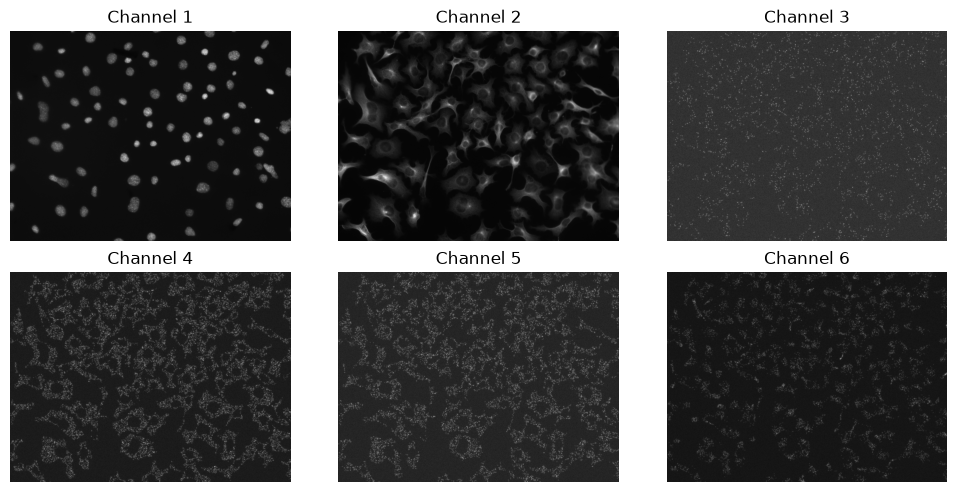

In [60]:
ch = 6
fig, axes = plt.subplots(2, ch // 2, figsize=(10, 5))
for i in range(ch):
    ax = axes[i // (ch // 2), i % (ch // 2)]
    ax.imshow(image[i], cmap="gray")
    ax.set_title(f"Channel {i + 1}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Initialize the Model

To initialize a pre-trained `Spotiflow` model, we can use the [`from_pretrained()`](https://weigertlab.org/spotiflow/api.html#spotiflow.model.spotiflow.Spotiflow.from_pretrained) class method.

Currently the available pre-trained models are:

- `general`: trained on a diverse dataset of spots of different modalities acquired in different microscopes with different settings.
- `hybiss`: trained on HybISS data acquired in 3 different microscopes
- `synth_complex`: trained on synthetic data, which includes simulations of aberrated spots and fluorescence background.
- `fluo_live`: trained on live-cell fluorescence imaging data corresponding to the Telomeres and Terra datasets in the manuscript.
- `synth_3d`: trained on synthetic 3D data, which includes simulations of aberrated spots and Z-related artifacts.
- `smfish_3d`: fine-tuned from the synth_3d model on smFISH 3D data of Platynereis dumerilii.

For this first example, we'll use the `general` model.

<p class="alert alert alert-info">
    <strong>Note:</strong> If you never used <code>Spotiflow</code> before, the model you will specify in the <code>from_pretrained()</code> method will be downloaded automatically the first time you run this notebook.
</p>

In [43]:
model = Spotiflow.from_pretrained("general")

INFO:spotiflow.model.spotiflow:Loading pretrained model: general


### Run Spotiflow

After initializing the model, we can run `Spotiflow` on the image using either the [`predict()`](https://weigertlab.org/spotiflow/api.html#spotiflow.model.spotiflow.Spotiflow.predict) or the `predict_multichannel()` (see the dropdown below) method from the initialized model.

<details>
<summary><b><code>predict_multichannel()</code> Parameters</b></summary>
<br>

<pre><code>model.predict_multichannel(
    img,
    channels=None,
    **predict_kwargs,
)</code></pre>

**Input**

| Parameter | Default | Description |
|:---|:---|:---|
| `img` | — | Multi-channel image in **channel-last** format: `(Y, X, C)` for 2D or `(Z, Y, X, C)` for 3D. |
| `channels` | `None` | An `int` or a tuple of channel indices to run the detection on. If `None`, runs on all channels. |
| `**predict_kwargs` | — | Any keyword argument accepted by `predict()`, forwarded to each channel (see the useful ones below). |

**`predict()` keyword arguments**

| Parameter | Default | Description |
|:---|:---|:---|
| `prob_thresh` | `None` | Probability threshold for peak detection. If `None`, uses the model's optimal value. |
| `min_distance` | `1` | Minimum distance (in pixels) allowed between two detected spots. |
| `scale` | `None` | Rescale factor applied to the image before detection. |
| `subpix` | `None` | Whether to refine spot positions to subpixel accuracy using the stereographic flow. If `None`, deduced from the model configuration. |
| `normalizer` | `"auto"` | Intensity normalization. `"auto"` uses percentile-based normalization (`p_min=1`, `p_max=99.8`). |
| `device` | `None` | Compute device to use: `"auto"`, `"cpu"`, `"cuda"` or `"mps"`. If `None`, inferred from the model location. |

**Returns**

A tuple `(points, details)`:

| Output | Description |
|:---|:---|
| `points` | numpy array of spot coordinates: `(N, 3)` for 2D as `(y, x, channel)` or `(N, 4)` for 3D as `(z, y, x, channel)`. The **last column is the index of the channel** the spot was detected in. |
| `details` | A **list** with one entry per processed channel, each holding that channel's `heatmap` (probability heatmap per pixel), `intens` (intensities of the detected spots), `prob` (probability of each spot being a true positive), `flow` (stereographic flow vector field) and `subpix` (2D local offset vector field). |

</details>

<br>

The difference between the two is:

- `predict()` runs the model on a **single-channel** image (a 2D `(Y, X)` image or a 3D `(Z, Y, X)` stack) and returns the spots detected in it.

- `predict_multichannel()` is designed for multi-channel data. It runs `predict()` on **each channel independently** and stacks the results, tagging every spot with the channel it was detected in. This is needed because the pre-trained models always work on a single channel at a time.

Since we are using a 2-channel image, we will use `predict_multichannel()`.

<p class="alert alert alert-info">
    ⚠️ Spotiflow expects the <strong>channel axis to be last</strong> (the image must be in <code>(Y, X, C)</code> shape).
    <br><br>
    ⚠️ In our case, the image is stored as <code>(C, Y, X)</code> so we need to move the channel axis to the end before running the model. We can do this easily with <a href="https://numpy.org/doc/stable/reference/generated/numpy.transpose.html"><strong>`numpy.transpose`</strong></a>.
</p>

In [44]:
tr_image = image.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
print(tr_image.shape)

(1040, 1392, 6)


Now we can run Spotiflow on the transposed image using the `predict_multichannel()`.

We need to pass to this function the `image` and which channel(s) to run the detection on (the `channel` parameter): we need to skip the first 2 channels (index 0 and 1) since they are the nuclei and the cytoplasm channels.

There could be other useful parameters to use (e.g. `prob_thresh`, `min_distance`, `subpix`), for simplicity we will only pass the two above.

As shown in the dropdown above, `predict_multichannel()` will return two outputs (a tuple):

- `points`: a numpy array containing the coordinates of the detected spots.

- `details`: a **list** with one entry per channel, each containing the spot-wise details for that channel including `heatmap`, `intens`, `prob`, `flow`, and `subpix`.


In [55]:
points, details = model.predict_multichannel(tr_image, channels=(2, 3, 4, 5))

INFO:spotiflow.model.spotiflow:Data is assumed to be in channel-last format ((Z)YXC).


Predicting channels:   0%|          | 0/4 [00:00<?, ?it/s]

### Explore, Display and Save the Results

#### Points

Let's explore the outputs starting from understanding the `points`.

What is the `shape` of `points`?

In [56]:
print(points.shape)

(35103, 3)


In [57]:
print(points[0])

[1038.40406823  968.1499027     2.        ]


Since we used `predict_multichannel()`, each row of `points` is in `(y, x, channel)` format. The last column is therefore the **index of the channel** the spot was detected in (would have been simply `(y, x)` if we had used `predict()` on a single-channel image).

To visualize the detected spots on top of the image we can use the `plot_points_on_image()` helper function we defined in the [Setup](#Setup) section of this notebook. This function takes as input the image and the points and plots the points on top of the image.

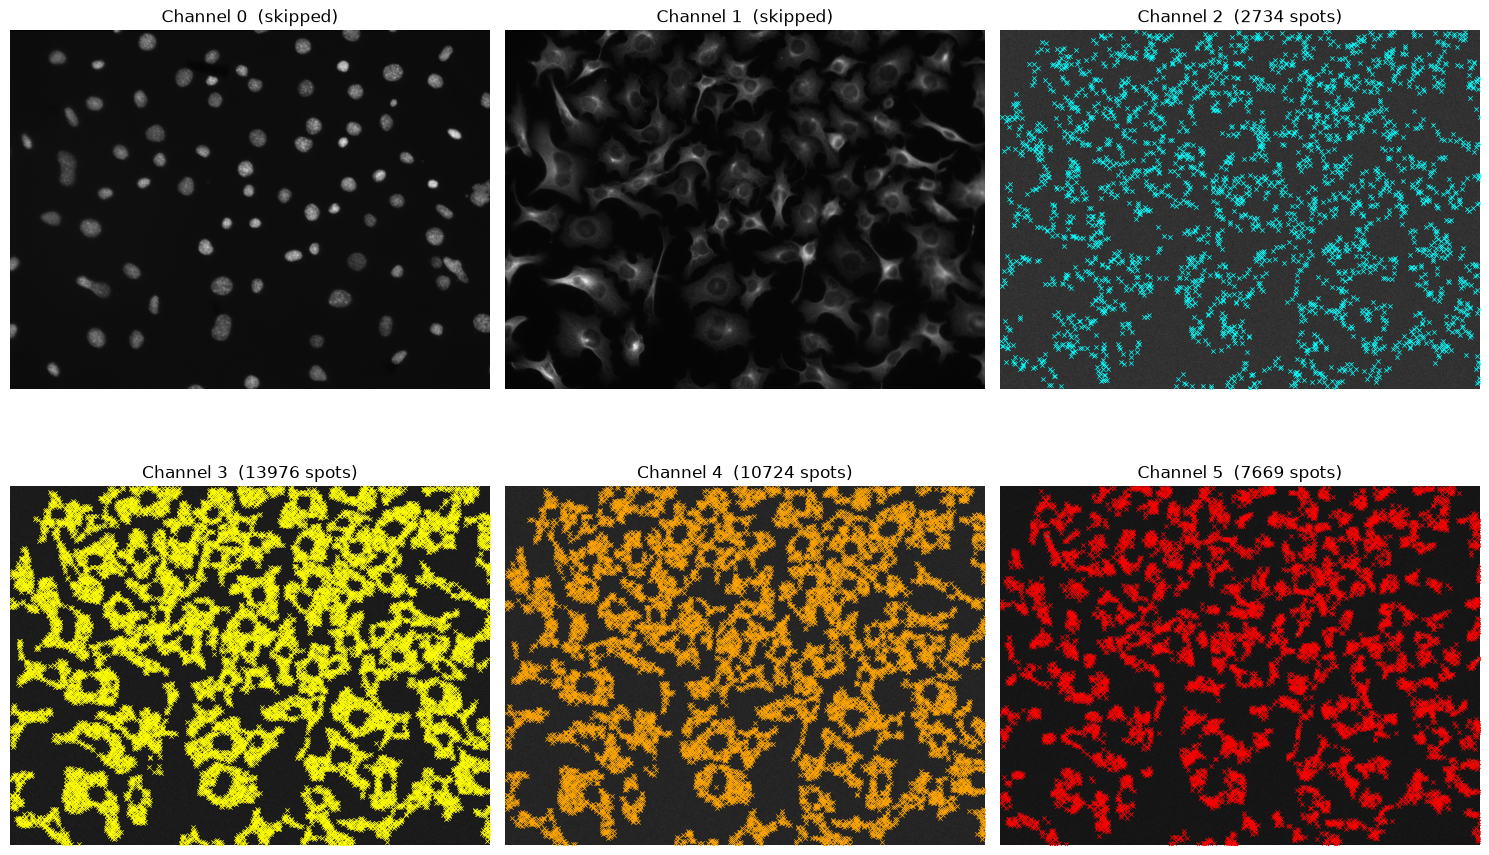

In [77]:
plot_points_on_image(image, points, skip_channels=[0, 1])

We can also save the detected spots for future use as a `csv` file using the `save_points_as_csv` function we defined in the [Setup](#Setup) section of this notebook.

<p class="alert alert alert-info">
    <strong>Note:</strong> This function is compatible with <code>napari</code>, so you can directly drag and drop the saved <code>csv</code> file in <code>napari</code> (together with the original multi-channel image) to visualize the detected spots as a points layer: each spot will appear on the channel it was detected in.
</p>

In [ ]:
save_points_as_csv(points, "2d_points.csv", channel_last=True)

#### Details

Let's have a look at the `details` output as well and let's focus in particular on the `heatmap` and the intensities (`intens`) of the detected spots.

`details` is a **list** with one entry per channel, each containing the spot-wise details for that channel including `heatmap`, `intens`, `prob`, `flow`, and `subpix`.

We can first plot the `heatmap` of the probabilities per pixel using the `imshow` method from the `matplotlib.pyplot` module.

Remember, `details` is a list, so we need to specify the channel index to visualize the heatmap of a specific channel.

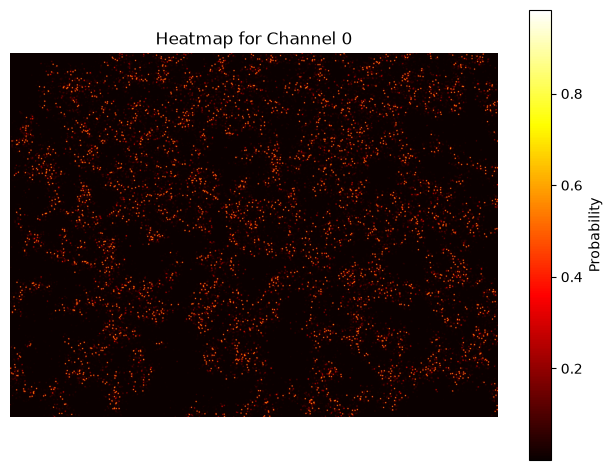

In [86]:
# `ch` is channel index, change it to visualize the heatmap of a different channel.
# note that this is the channel index as passed to predict_multichannel().
ch = 0

plt.imshow(details[ch].heatmap, cmap="hot")
plt.colorbar(label="Probability")
plt.title(f"Heatmap for Channel {ch}")
plt.axis("off")
plt.tight_layout()
plt.show()

In `details[channel].intens` we can find the value of the pixel in the original image at the coordinates of each detected spot, which can be used as a measure of the intensity of the detected spots.

We can visualize the distribution of these intensities with a histogram using `hist` from `matplotlib.pyplot`.

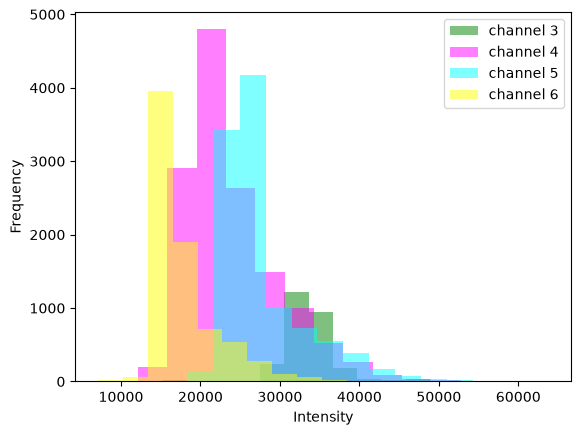

In [87]:
plt.hist(details[0].intens, bins=15, color="green", alpha=0.5, label="channel 3")
plt.hist(details[1].intens, bins=15, color="magenta", alpha=0.5, label="channel 4")
plt.hist(details[2].intens, bins=15, color="cyan", alpha=0.5, label="channel 5")
plt.hist(details[3].intens, bins=15, color="yellow", alpha=0.5, label="channel 6")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Running Spotiflow on a Folder of Images

To run `Spotiflow` on a folder of multi-channel images, we can simply loop over the files in the folder, load the images with `tifffile`, and run `predict_multichannel()` on each of them. To save the points, we can use the `save_points_as_csv` function we defined in the [Setup](#Setup) section of this notebook.

In [ ]:
# Path to the folder containing the images
folder_path = Path("data/00_spot_detection/")  # change this to your folder path

# Get the sorted list of all .tif images in the folder
images_path = sorted(folder_path.glob("*.tif"))

# Initialize the model once before the loop
model = Spotiflow.from_pretrained("general")

# specify the channels you want to process in predict_multichannel()
channels = (2, 3, 4, 5)

# NOTE: tqdm is used to show a progress bar, but you can remove it if you don't want it
for image_path in tqdm(images_path, desc="Processing images"):
    # Load the image
    image = tifffile.imread(image_path)
    # Transpose the image to channel-last format for `predict_multichannel`
    tr_image = image.transpose(1, 2, 0)  # (C, Y, X) -> (Y, X, C)
    # Run Spotiflow on the image
    points, details = model.predict_multichannel(tr_image, channels=channels)
    # Save the points as a CSV file
    output_path = folder_path / f"{image_path.stem}_points.csv"
    save_points_as_csv(points, str(output_path), channel_last=True)

## Bonus: Running Spotiflow on 3D images

Running `Spotiflow` on 3D images is very similar to running it on 2D images. The only differences are that the input image is a 3D stack in `(Z, Y, X)` format (single-channel) or `(Z, Y, X, C)` (multi-channel), and the output `points` will be in `(z, y, x)` or `(z, y, x, channel)` format respectively.

### Load and Visualize the Image

In [27]:
image_path = "data/spot_detection/3d_spots.tif"
image_3d = tifffile.imread(image_path)

print(image_3d.shape)

(256, 256, 256)


We can visualize the stack as a **max projection along Z** using a combination of `numpy` and `matplotlib`.

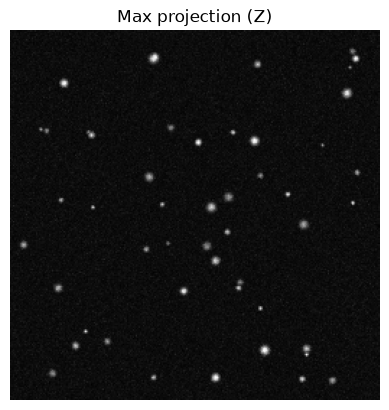

In [28]:
plt.imshow(image_3d.max(axis=0), cmap="gray")
plt.title("Max projection (Z)")
plt.axis("off")
plt.show()

### Initialize the Model

For 3D datasets, we need to use a pre-trained model that has been trained on 3D data, either `synth_3d` or `smfish_3d`. In this example, we will use the `smfish_3d` model.

In [29]:
model = Spotiflow.from_pretrained("smfish_3d")

INFO:spotiflow.model.spotiflow:Loading pretrained model: smfish_3d


### Run Spotiflow

In this example we are using a single-channel z-stack, so we can use the `predict()` method. We also **do not** need to transpose the image since it is already in the required `(Z, Y, X)` format.

In [30]:
points, details = model.predict(image_3d)

INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.4], min_distance = 1
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (256, 256, 256)
INFO:spotiflow.model.spotiflow:Predicting with (2, 1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (256, 256, 256, 1)
INFO:spotiflow.model.spotiflow:Correcting internal min_distance to 0.5 due to grid: (2, 2, 2).


Predicting tiles:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:spotiflow.model.spotiflow:Found 50 spots


In [31]:
points[0]  # z, y, x

array([119.02334154, 133.99904844, 203.01079941])

### Display and Save the Results

#### Points

The `points` coordinates are in `(z, y, x)` format. We can visualize them overlaid on the max projection using `plot_points_on_image` with `is_3d=True`.

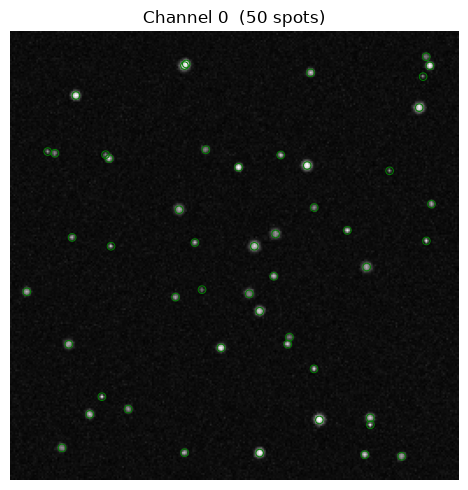

In [32]:
plot_points_on_image(image_3d, points, is_3d=True)

We can save the detected spots using the `save_points_as_csv` helper defined in the [Setup](#Setup) section.

In [ ]:
save_points_as_csv(points, "3d_points.csv")

#### Details

We can also visualize the `heatmap` and the intensity distribution of the detected spots as we did for 2D images.

Again, using a combination of `numpy` and `matplotlib`, we can display the `heatmap` as a max projection along Z, and the intensity distribution with a histogram.

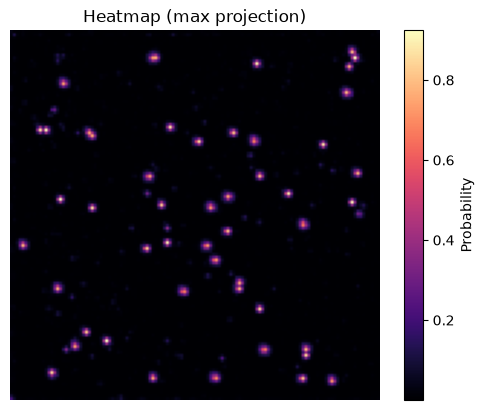

In [33]:
plt.imshow(details.heatmap.max(axis=0), cmap="magma")
plt.title("Heatmap (max projection)")
plt.colorbar(label="Probability")
plt.axis("off")
plt.show()

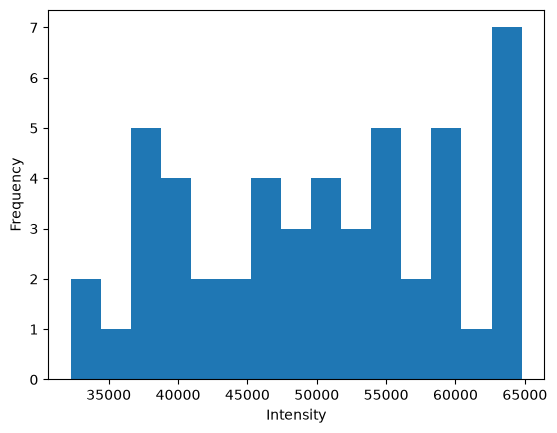

In [34]:
plt.hist(details.intens, bins=15)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()